Imports (Remember to put all of the imports in the beginning ;p)

In [10]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [3]:
csv_path = Path('/home/filipepimentel/Desktop/Thesis code/lyrics_twitter_final.csv')
analysis_df = pd.read_csv(csv_path)
analysis_df.head()

,artist,title,disorder,bert_emotion,bert_confidence,lyrics_clean,go_multi_labels,go_multi_scores,go_emotion,go_confidence,go_valence,go_arousal,vad_valence,vad_arousal,va_distance,valence,arousal
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,joy,0.983130,Highest To Lowest: Quadeca LyricsQuadeca's Son...,disappointment,disappointment:0.0380,neutral,0.7992,-0.0373,0.0370,5.2587,5.6958,7.750460,0.300440,0.333046
1,Tom Jones,She's A Lady,control,joy,0.503159,She's a Lady Lyrics Well she's all you'd ever ...,admiration | approval,admiration:0.7320 | approval:0.2649,admiration,0.7320,0.7431,0.3167,5.4373,6.1020,7.450182,0.263476,0.375775
2,David Byrne,Lilies of the Valley,control,sadness,0.994102,Lilies of the Valley Lyrics Momma she had comp...,approval,approval:0.0948,neutral,0.6730,0.0757,0.0733,4.3560,5.9713,7.287481,0.344658,0.199640
3,Alice Cooper,School's Out,control,sadness,0.925512,"School's Out Lyrics Well, we got no choice All...",annoyance | disappointment | disapproval,annoyance:0.1691 | disappointment:0.1335 | dis...,neutral,0.5905,-0.2450,0.0458,4.1307,5.8503,7.269042,-0.703709,-0.349047
4,Alice Cooper,School's Out,control,sadness,0.925512,"School's Out Lyrics Well, we got no choice All...",annoyance | disappointment | disapproval,annoyance:0.1691 | disappointment:0.1335 | dis...,neutral,0.5905,-0.2450,0.0458,4.1307,5.8503,7.269042,-0.703709,-0.349047


In [6]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [9]:
analysis_df.columns = (
    analysis_df.columns
    .str.replace('\n', '', regex=False)
    .str.strip() 
)

for col in analysis_df.columns:
    try:
        analysis_df[col] = pd.to_numeric(analysis_df[col])
    except (ValueError, TypeError):
        pass

print('Shape:', analysis_df.shape)
print('Columns', list(analysis_df.columns))

Shape: (1338831, 17)
Columns ['artist', 'title', 'disorder', 'bert_emotion', 'bert_confidence', 'lyrics_clean', 'go_multi_labels', 'go_multi_scores', 'go_emotion', 'go_confidence', 'go_valence', 'go_arousal', 'vad_valence', 'vad_arousal', 'va_distance', 'valence', 'arousal']


In [11]:
numeric_cols = analysis_df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)

Numeric columns: ['bert_confidence', 'go_confidence', 'go_valence', 'go_arousal', 'vad_valence', 'vad_arousal', 'va_distance', 'valence', 'arousal']


In [17]:
# Normlization of vad_valence and vad_arousal
analysis_df_norm = analysis_df.copy()
scaler = MinMaxScaler(feature_range=(-1, 1))
analysis_df_norm[['vad_valence', 'vad_arousal']] = scaler.fit_transform(analysis_df_norm[['vad_valence', 'vad_arousal']])
analysis_df_norm[numeric_cols].head()

,bert_confidence,go_confidence,go_valence,go_arousal,vad_valence,vad_arousal,va_distance,valence,arousal
0,0.983130,0.7992,-0.0373,0.0370,0.119019,-0.123683,7.750460,0.300440,0.333046
1,0.503159,0.7320,0.7431,0.3167,0.186845,0.098030,7.450182,0.263476,0.375775
2,0.994102,0.6730,0.0757,0.0733,-0.223796,0.026691,7.287481,0.344658,0.199640
3,0.925512,0.5905,-0.2450,0.0458,-0.309357,-0.039354,7.269042,-0.703709,-0.349047
4,0.925512,0.5905,-0.2450,0.0458,-0.309357,-0.039354,7.269042,-0.703709,-0.349047


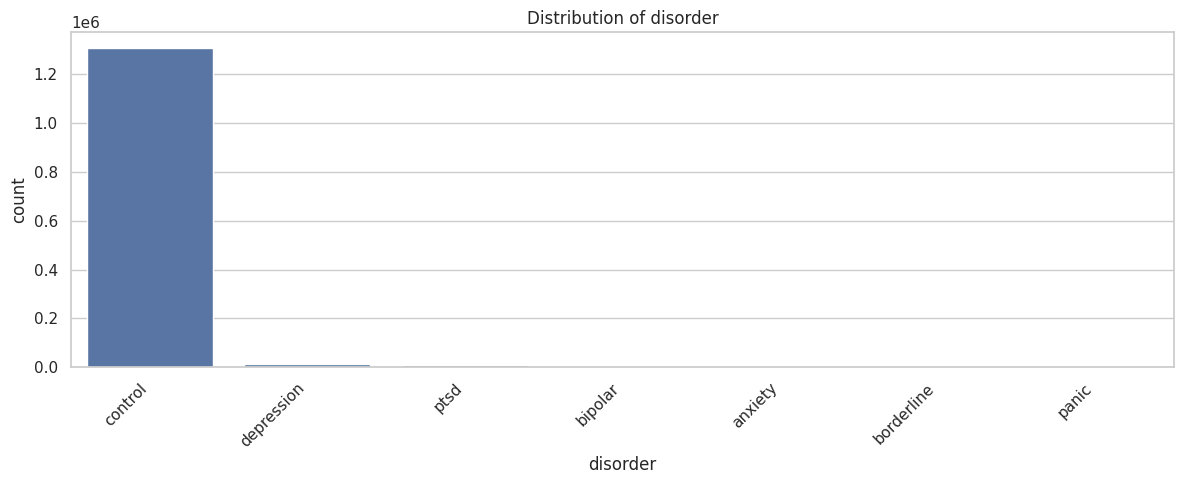

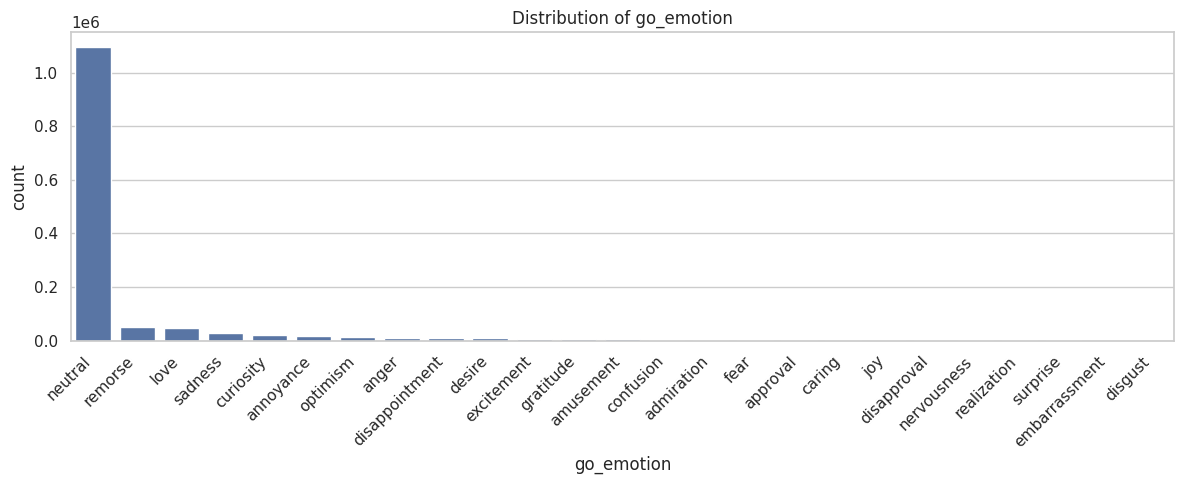

In [18]:
if "disorder" in analysis_df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=analysis_df, x="disorder", order=analysis_df["disorder"].value_counts().index)
    plt.title("Distribution of disorder")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if "go_emotion" in analysis_df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=analysis_df, x="go_emotion", order=analysis_df["go_emotion"].value_counts().index)
    plt.title("Distribution of go_emotion")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

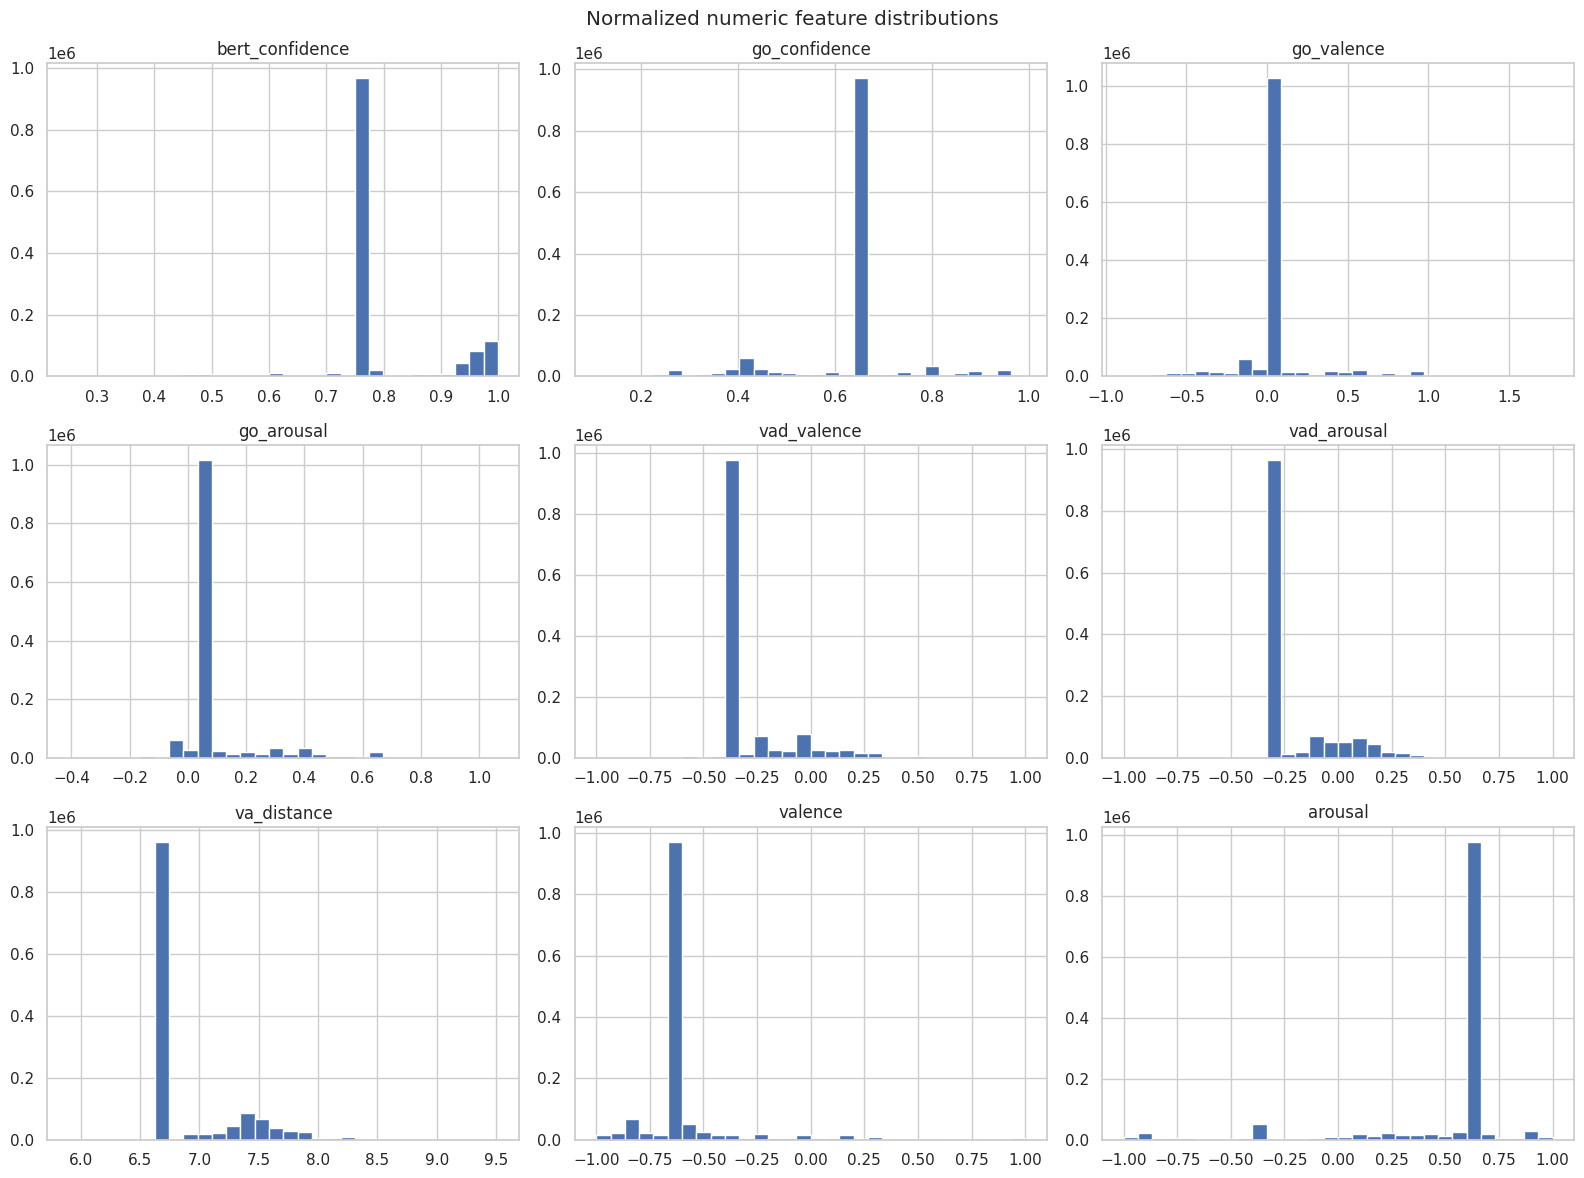

In [19]:
# --- 2) Histograms of numeric features (normalized) ---
analysis_df_norm[numeric_cols].hist(bins=30, figsize=(16, 12))
plt.suptitle("Normalized numeric feature distributions")
plt.tight_layout()
plt.show()

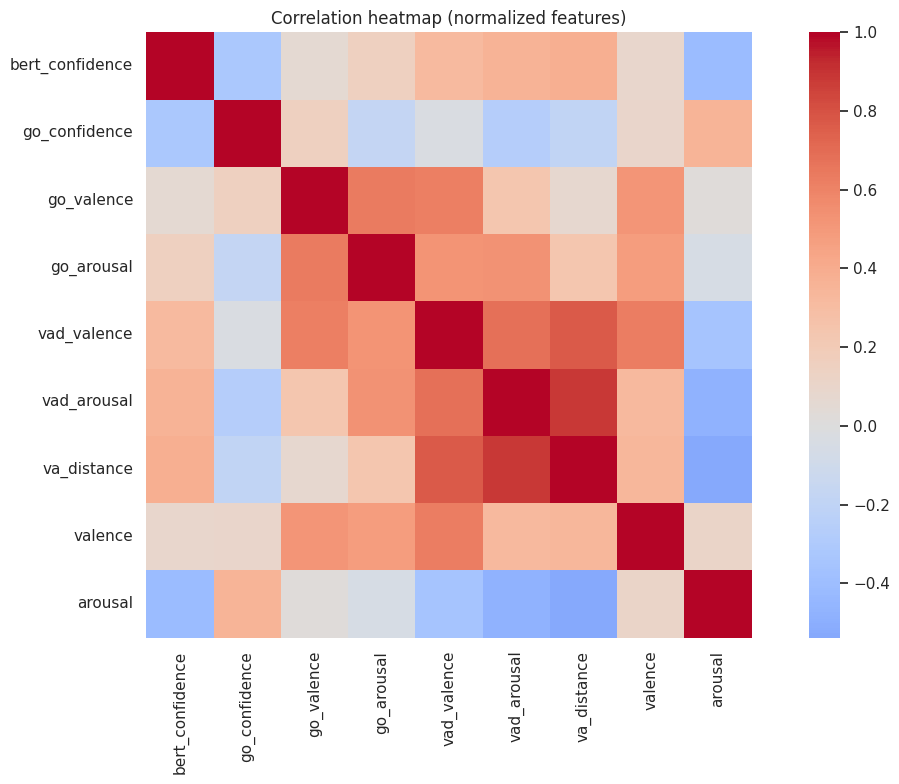

In [20]:
plt.figure(figsize=(12, 8))
corr = analysis_df_norm[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation heatmap (normalized features)")
plt.tight_layout()
plt.show()

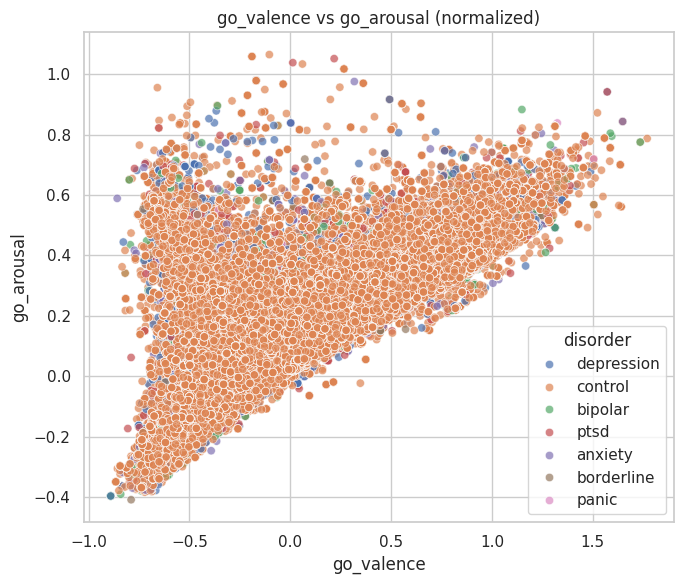

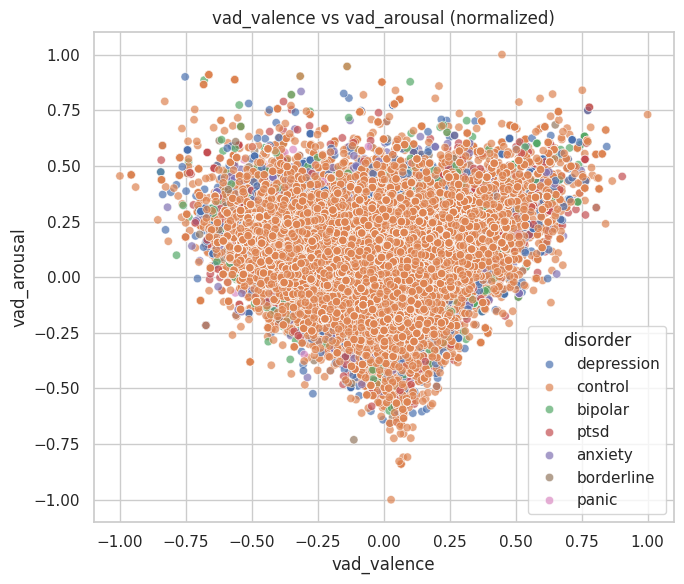

/tmp/ipykernel_6626/1439486316.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/filipepimentel/quantum/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


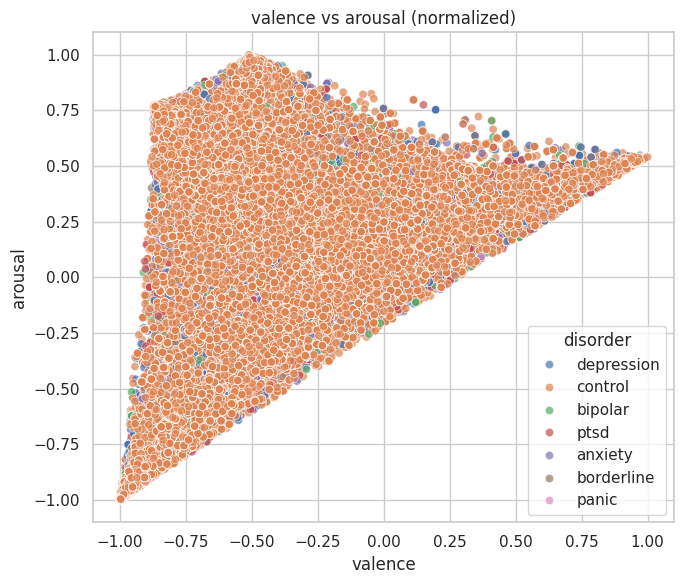

In [21]:
# --- 4) Valence-Arousal scatter (if columns exist) ---
# Tries both GO and VAD versions
va_pairs = [
    ("go_valence", "go_arousal"),
    ("vad_valence", "vad_arousal"),
    ("valence", "arousal"),
]

for x_col, y_col in va_pairs:
    if x_col in analysis_df_norm.columns and y_col in analysis_df_norm.columns:
        plt.figure(figsize=(7, 6))
        hue_col = "disorder" if "disorder" in analysis_df_norm.columns else None
        sns.scatterplot(data=analysis_df_norm, x=x_col, y=y_col, hue=hue_col, alpha=0.7)
        plt.title(f"{x_col} vs {y_col} (normalized)")
        plt.tight_layout()
        plt.show()

In [22]:
# Cell 2 - Keep only GoEmotion/VAD dimensions we care about
df_base = analysis_df_norm.copy() if "analysis_df_norm" in globals() else analysis_df.copy()
dep_df = df_base[df_base["disorder"].astype(str).str.lower().str.contains("depress", na=False)].copy()
target_cols = ["go_valence", "go_arousal", "vad_valence", "vad_arousal"]
available_cols = [c for c in target_cols if c in dep_df.columns]

if len(available_cols) < 2:
    raise ValueError("Not enough GoEmotion/VAD columns found in this dataframe.")

# Coerce to numeric where possible
for c in available_cols:
    dep_df[c] = pd.to_numeric(dep_df[c], errors="coerce")

print("Using columns:", available_cols)
print(dep_df[available_cols].isna().mean().sort_values())

Using columns: ['go_valence', 'go_arousal', 'vad_valence', 'vad_arousal']
go_valence     0.0
go_arousal     0.0
vad_valence    0.0
vad_arousal    0.0
dtype: float64


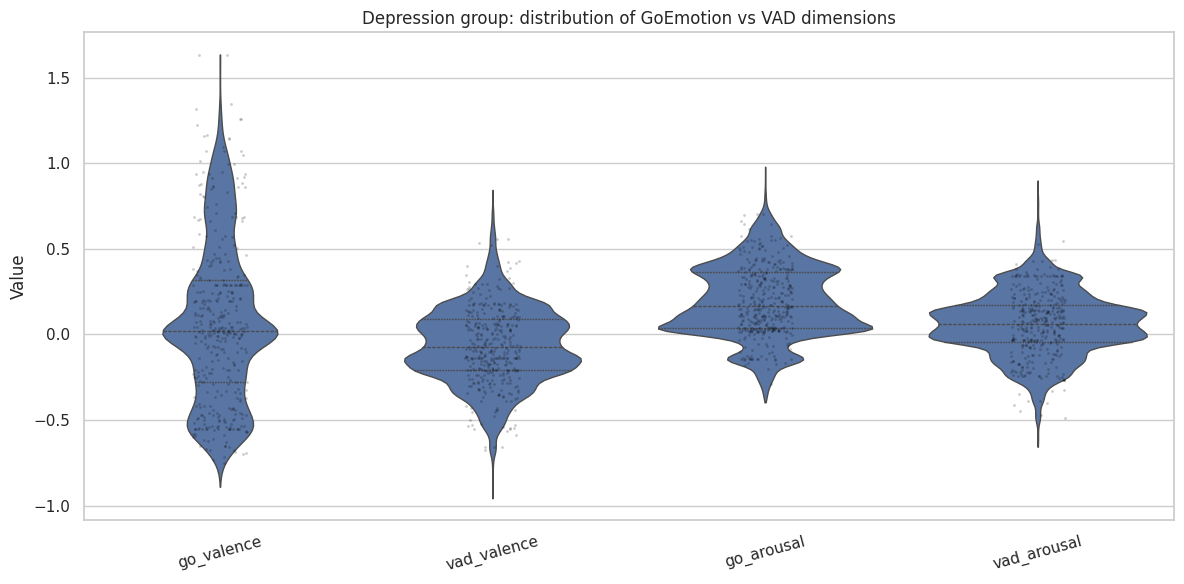

In [23]:
# Cell 3 - Distribution comparison (violin + strip)
plot_cols = [c for c in ["go_valence", "vad_valence", "go_arousal", "vad_arousal"] if c in dep_df.columns]

long_df = dep_df[plot_cols].melt(var_name="feature", value_name="value").dropna()

plt.figure(figsize=(12, 6))
sns.violinplot(data=long_df, x="feature", y="value", inner="quartile", cut=0, linewidth=1)
sns.stripplot(data=long_df.sample(min(1500, len(long_df)), random_state=42),
              x="feature", y="value", color="black", alpha=0.20, size=2)
plt.title("Depression group: distribution of GoEmotion vs VAD dimensions")
plt.xlabel("")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

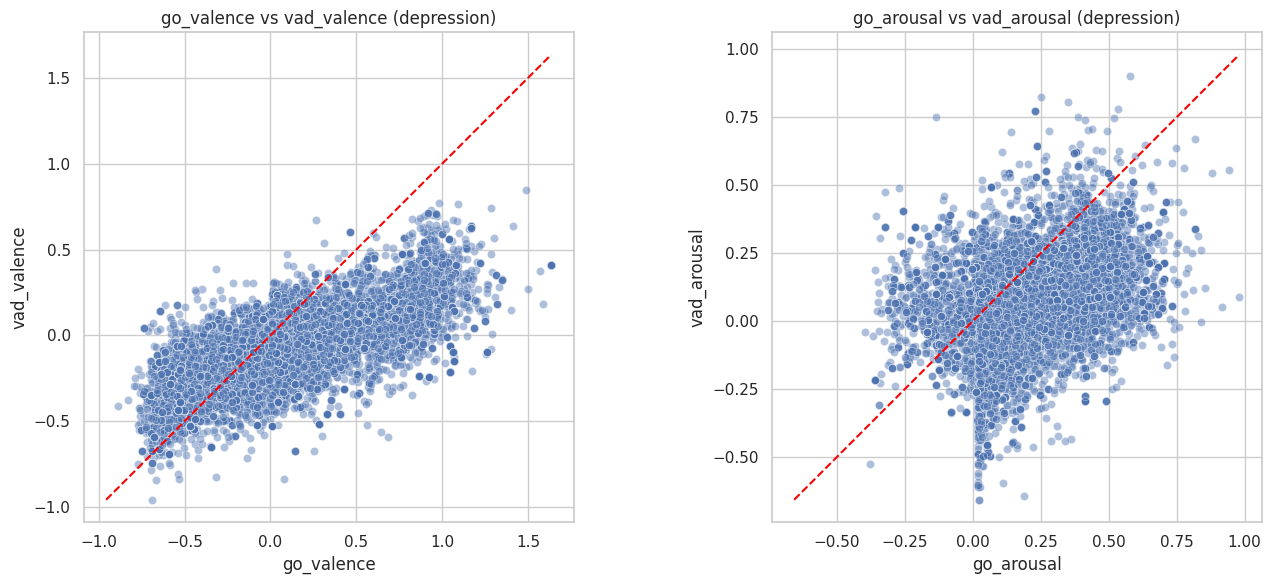

In [24]:
# Cell 4 - Model agreement scatter with reference line y=x
pairs = [("go_valence", "vad_valence"), ("go_arousal", "vad_arousal")]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (x, y) in zip(axes, pairs):
    if x in dep_df.columns and y in dep_df.columns:
        tmp = dep_df[[x, y]].dropna()
        sns.scatterplot(data=tmp, x=x, y=y, alpha=0.45, s=35, ax=ax)
        lo = np.nanmin([tmp[x].min(), tmp[y].min()])
        hi = np.nanmax([tmp[x].max(), tmp[y].max()])
        ax.plot([lo, hi], [lo, hi], linestyle="--", color="red", linewidth=1.5)
        ax.set_title(x + " vs " + y + " (depression)")
        ax.set_aspect("equal", adjustable="box")
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

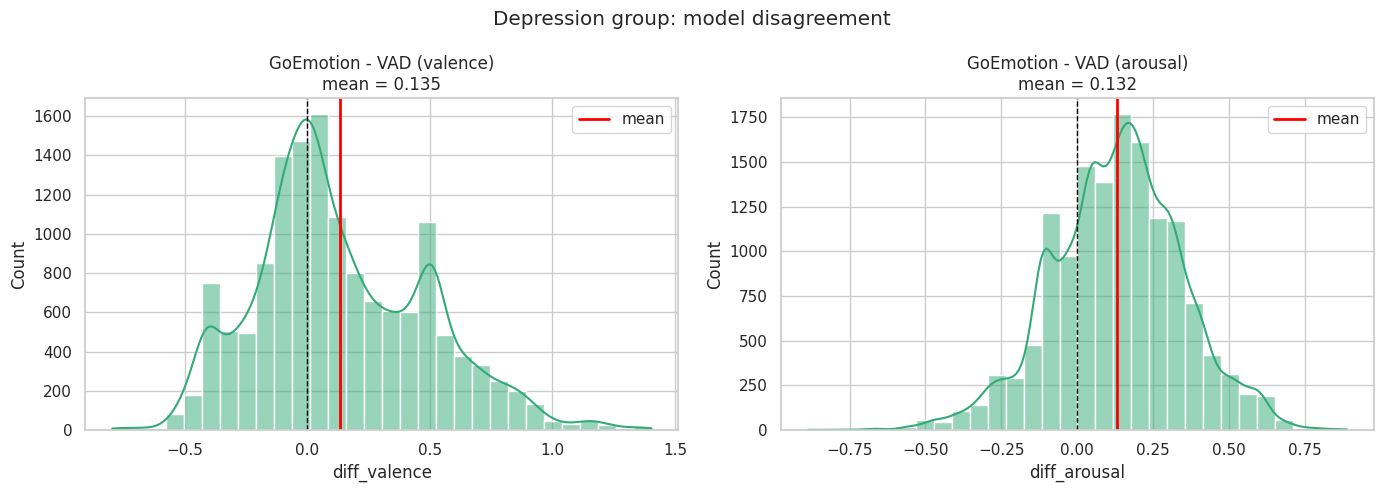

In [25]:
# Cell 5 - Disagreement plot (difference distributions)
diff_cols = {}
if {"go_valence", "vad_valence"}.issubset(dep_df.columns):
    dep_df["diff_valence"] = dep_df["go_valence"] - dep_df["vad_valence"]
    diff_cols["diff_valence"] = "GoEmotion - VAD (valence)"
if {"go_arousal", "vad_arousal"}.issubset(dep_df.columns):
    dep_df["diff_arousal"] = dep_df["go_arousal"] - dep_df["vad_arousal"]
    diff_cols["diff_arousal"] = "GoEmotion - VAD (arousal)"

if diff_cols:
    fig, axes = plt.subplots(1, len(diff_cols), figsize=(7 * len(diff_cols), 5))
    if len(diff_cols) == 1:
        axes = [axes]

    for ax, c in zip(axes, diff_cols.keys()):
        d = dep_df[c].dropna()
        sns.histplot(d, kde=True, bins=30, ax=ax, color="#3A7")
        ax.axvline(0, linestyle="--", color="black", linewidth=1)
        ax.axvline(d.mean(), linestyle="-", color="red", linewidth=2, label="mean")
        ax.set_title(diff_cols[c] + "\nmean = " + f"{d.mean():.3f}")
        ax.legend()

    plt.suptitle("Depression group: model disagreement")
    plt.tight_layout()
    plt.show()
else:
    print("Difference columns could not be built (missing required features).")

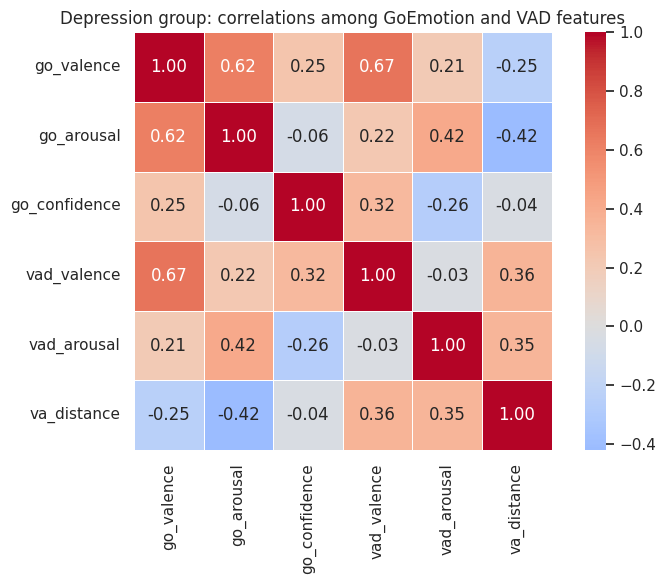

In [26]:
# Cell 6 - Correlation heatmap focused on interpretability features
heat_cols = [c for c in ["go_valence", "go_arousal", "go_confidence", "vad_valence", "vad_arousal", "va_distance"] if c in dep_df.columns]
corr_dep = dep_df[heat_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_dep, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Depression group: correlations among GoEmotion and VAD features")
plt.tight_layout()
plt.show()

In [27]:
# Cell 7 - Most interpretable samples: largest model disagreement
show_cols = ["artist", "title", "disorder", "go_valence", "vad_valence", "go_arousal", "vad_arousal", "go_confidence", "va_distance"]
show_cols = [c for c in show_cols if c in dep_df.columns]

if {"go_valence", "vad_valence", "go_arousal", "vad_arousal"}.issubset(dep_df.columns):
    dep_df["abs_disagreement"] = (
        (dep_df["go_valence"] - dep_df["vad_valence"]).abs() +
        (dep_df["go_arousal"] - dep_df["vad_arousal"]).abs()
    )
    top_disagree = dep_df.sort_values("abs_disagreement", ascending=False)[show_cols + ["abs_disagreement"]].head(15)
    display(top_disagree)
else:
    print("Could not compute abs_disagreement because some required columns are missing.")

,artist,title,disorder,go_valence,vad_valence,go_arousal,vad_arousal,go_confidence,va_distance,abs_disagreement
1095383,King Gizzard & The Lizard Wizard,Work This Time,depression,1.2897,0.006608,0.7333,-0.084057,0.7981,6.232428,2.100449
1008602,Victoria Monét,Experience,depression,1.4036,0.150691,0.7410,-0.001310,0.7044,6.506445,1.995219
1107754,Sir Chloe,July,depression,1.1751,-0.209023,0.6966,0.139021,0.8306,6.356335,1.941702
988074,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
1005045,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
1005044,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
988076,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
988073,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
1005046,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
1005047,Olivia Rodrigo,happier,depression,1.2618,-0.095549,0.7033,0.156105,0.5130,6.487223,1.904544
